In [1]:
# =====================================================
# INSTALL AND SETUP PYSPARK IN COLAB
# =====================================================

# Install Java 8 (required for PySpark)
!apt-get update
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

# Set Java environment variables
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

# Install PySpark
!pip install pyspark==3.5.0

# Install additional dependencies
!pip install findspark

print("PySpark setup completed successfully!")

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
PySpark setup 

In [2]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, lower, count
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from pyspark.sql.types import DoubleType
from pyspark.java_gateway import launch_gateway
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import findspark
import os
%matplotlib inline

The previous error `ModuleNotFoundError: No module named 'findspark'` indicates that the necessary library to help PySpark locate Spark was not installed.

The following cell installs `findspark`.

In [3]:
# =====================================================
#  INITIALIZE SPARK SESSION
# =====================================================
findspark.init()

spark = SparkSession.builder \
    .appName("Goodreads_LogisticRegression_From_Scratch") \
    .getOrCreate()

In [4]:
# =====================================================
#  LOAD AND CLEAN DATA
# =====================================================
print("\n Loading Dataset...")
df = spark.read.csv("GoodReads_100k_books.csv", header=True, inferSchema=True)
df.show(5)

# Inspect expected columns
expected_cols = ['rating', 'reviews', 'pages', 'totalratings', 'genre', 'bookformat']
existing_cols = [c for c in expected_cols if c in df.columns]
print("Using columns:", existing_cols)

# Keep only relevant columns
df = df.select(*existing_cols)

# Cast numeric columns to DoubleType, coercing errors to nulls
for c in ['rating', 'reviews', 'pages', 'totalratings']:
    if c in df.columns:
        df = df.withColumn(c, col(c).cast(DoubleType()))

# Drop rows with nulls introduced by casting errors
df = df.dropna()

# Lowercase categorical columns for consistency
if 'genre' in df.columns:
    df = df.withColumn('genre', lower(col('genre')))
if 'bookformat' in df.columns:
    df = df.withColumn('bookformat', lower(col('bookformat')))

print(f" Loaded {df.count()} records after cleaning")
df.show(5)


 Loading Dataset...
+--------------------+----------+--------------------+--------------------+--------------------+--------------------+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|              author|bookformat|                desc|               genre|                 img|                isbn|           isbn13|                link|               pages|              rating|             reviews|               title|        totalratings|
+--------------------+----------+--------------------+--------------------+--------------------+--------------------+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|Laurence M. Hauptman| Hardcover|Reveals that seve...|History,Military ...|https://i.gr-asse...|          002914180X|         9.78E+12|https://goodreads...|                   0|                

In [5]:
# =====================================================
# CREATE TARGET VARIABLE (BESTSELLER)
# =====================================================
# Cast 'totalratings' to DoubleType before calculating the median
df = df.withColumn("totalratings", col("totalratings").cast(DoubleType()))

median_total = df.approxQuantile("totalratings", [0.5], 0.01)[0]
df = df.withColumn("bestseller", when(col("totalratings") > median_total, 1).otherwise(0))

print(f" Bestseller threshold (median total ratings): {median_total}")
print(" Dataset schema:")
df.printSchema()

 Bestseller threshold (median total ratings): 195.0
 Dataset schema:
root
 |-- rating: double (nullable = true)
 |-- reviews: double (nullable = true)
 |-- pages: double (nullable = true)
 |-- totalratings: double (nullable = true)
 |-- genre: string (nullable = true)
 |-- bookformat: string (nullable = true)
 |-- bestseller: integer (nullable = false)



In [6]:
# =====================================================
# PREPARE CATEGORICAL FEATURES (GENRE & BOOKFORMAT)
# =====================================================
print("\n Preparing categorical features...")

# Get top categories for genre and bookformat to avoid too many dummy variables
if 'genre' in df.columns:
    genre_counts = df.groupBy('genre').count().orderBy('count', ascending=False)
    top_genres = [row['genre'] for row in genre_counts.limit(15).collect()]
    print(f"Top 15 genres: {top_genres}")

if 'bookformat' in df.columns:
    format_counts = df.groupBy('bookformat').count().orderBy('count', ascending=False)
    top_formats = [row['bookformat'] for row in format_counts.limit(10).collect()]
    print(f"Top 10 book formats: {top_formats}")


 Preparing categorical features...
Top 15 genres: ['nonfiction', 'history', 'games,chess', 'esoterica,astrology', 'poetry', 'fiction', 'combat,martial arts', 'history,nonfiction', 'music', 'crafts,quilting', 'literature,marathi', 'science,mathematics', 'childrens', 'occult,tarot', 'art']
Top 10 book formats: ['paperback', 'hardcover', 'ebook', 'kindle edition', 'mass market paperback', 'unknown binding', 'nook', 'audio cd', 'board book', 'spiral-bound']



 Running EDA...


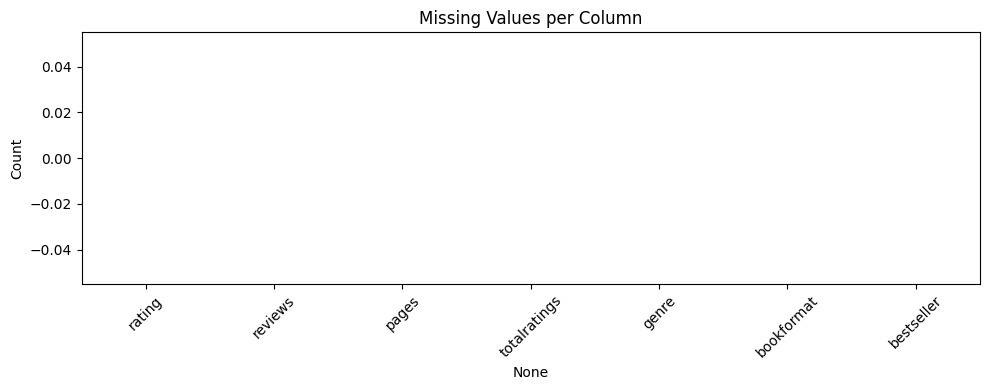

In [7]:
# =====================================================
# EDA + VISUALIZATION (AUTO-SAVE)
# =====================================================
output_dir = "outputs/EDA_Visuals"
os.makedirs(output_dir, exist_ok=True)

# Sample data for EDA (to avoid overloading with large datasets)
eda_sample = df.sample(fraction=0.05, seed=42).toPandas()

print("\n Running EDA...")

# --- Missing Values ---
missing = eda_sample.isnull().sum().sort_values(ascending=False)
plt.figure(figsize=(10,4))
sns.barplot(x=missing.index, y=missing.values)
plt.title("Missing Values per Column")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f"{output_dir}/missing_values.png")
plt.show()
plt.close()

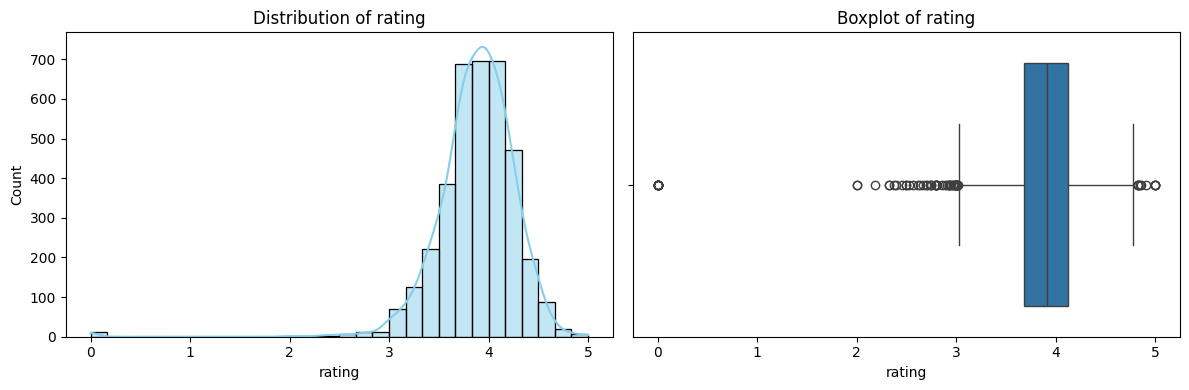

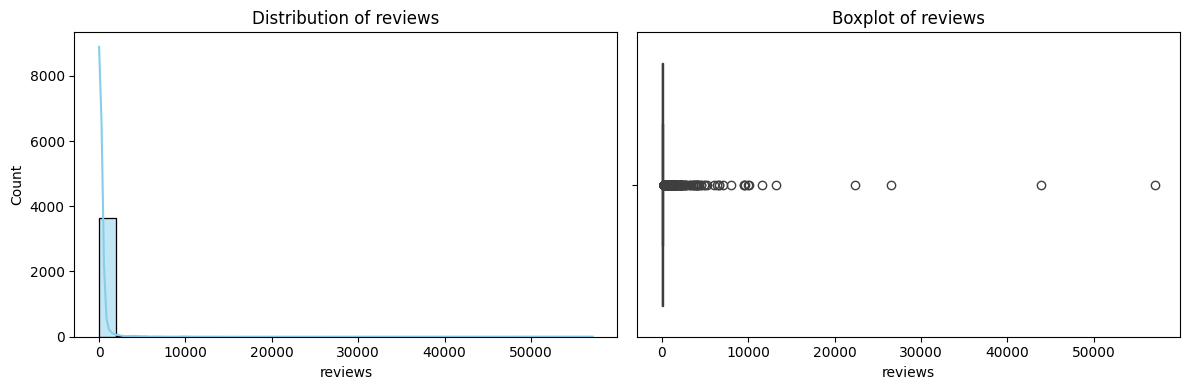

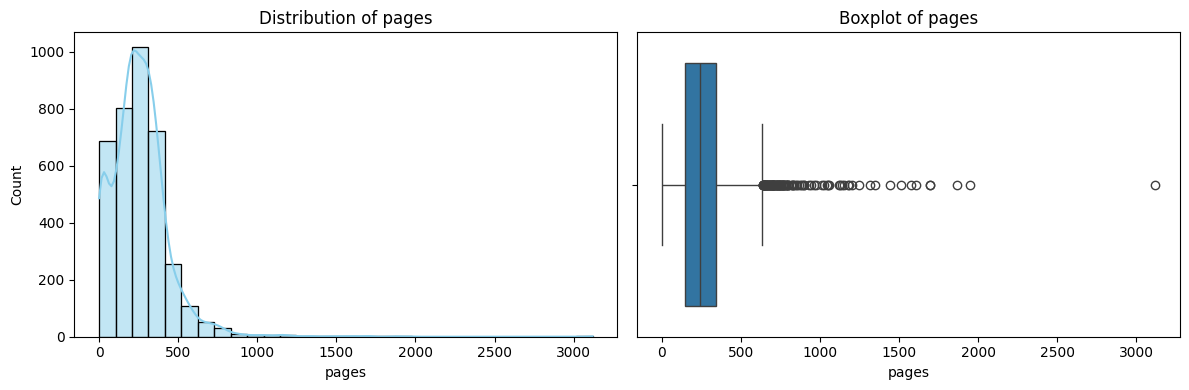

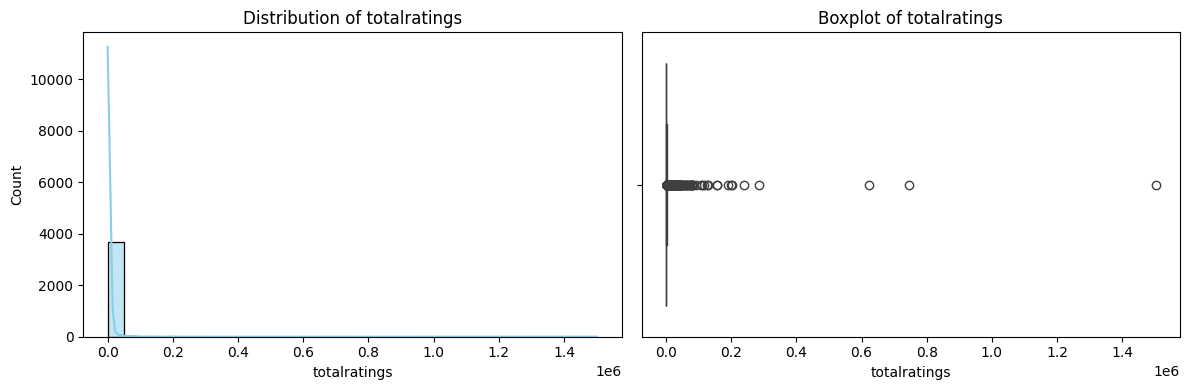

In [8]:
# --- Numeric Distributions ---
numeric_cols = ['rating', 'reviews', 'pages', 'totalratings']
for col_name in numeric_cols:
    if col_name in eda_sample.columns:
        # Histogram
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        sns.histplot(eda_sample[col_name].dropna(), bins=30, kde=True, color='skyblue')
        plt.title(f"Distribution of {col_name}")

        plt.subplot(1, 2, 2)
        sns.boxplot(x=eda_sample[col_name].dropna())
        plt.title(f"Boxplot of {col_name}")

        plt.tight_layout()
        plt.savefig(f"{output_dir}/distribution_{col_name}.png")
        plt.show()
        plt.close()

/tmp/ipython-input-345938811.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette="mako")


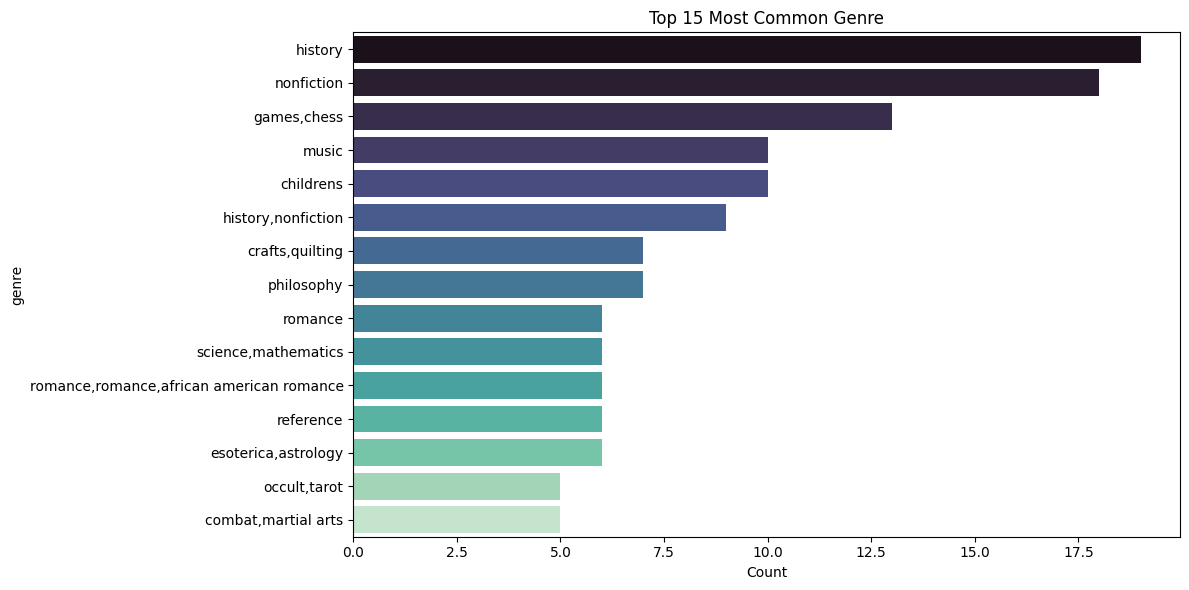

/tmp/ipython-input-345938811.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette="mako")


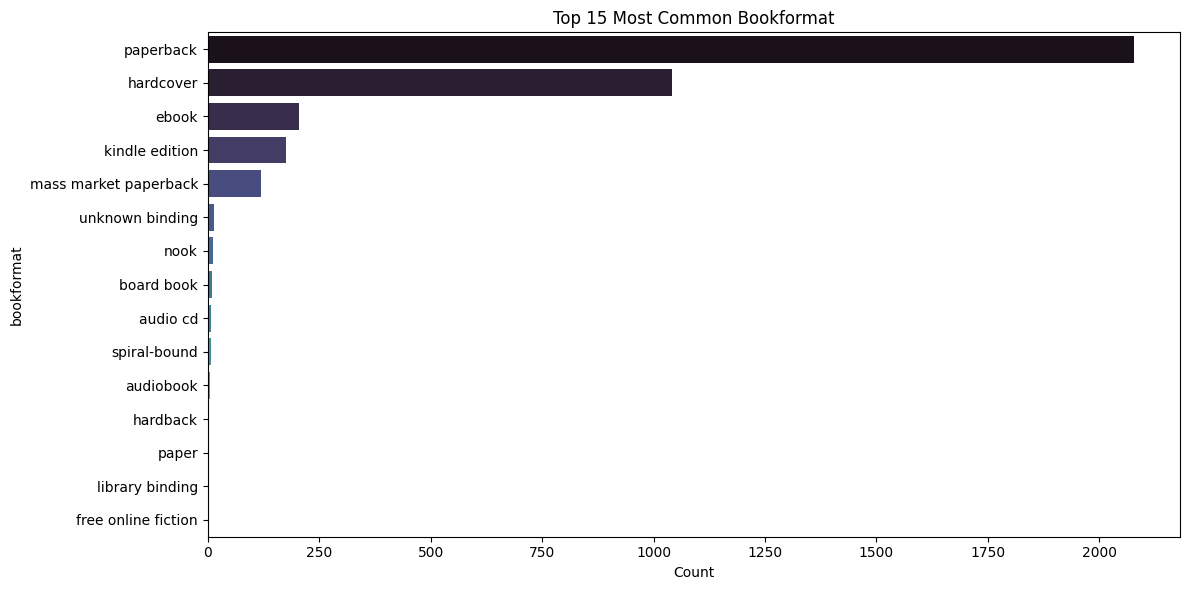

/tmp/ipython-input-345938811.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bestseller_by_genre.values, y=bestseller_by_genre.index, palette="viridis")
/tmp/ipython-input-345938811.py:21: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


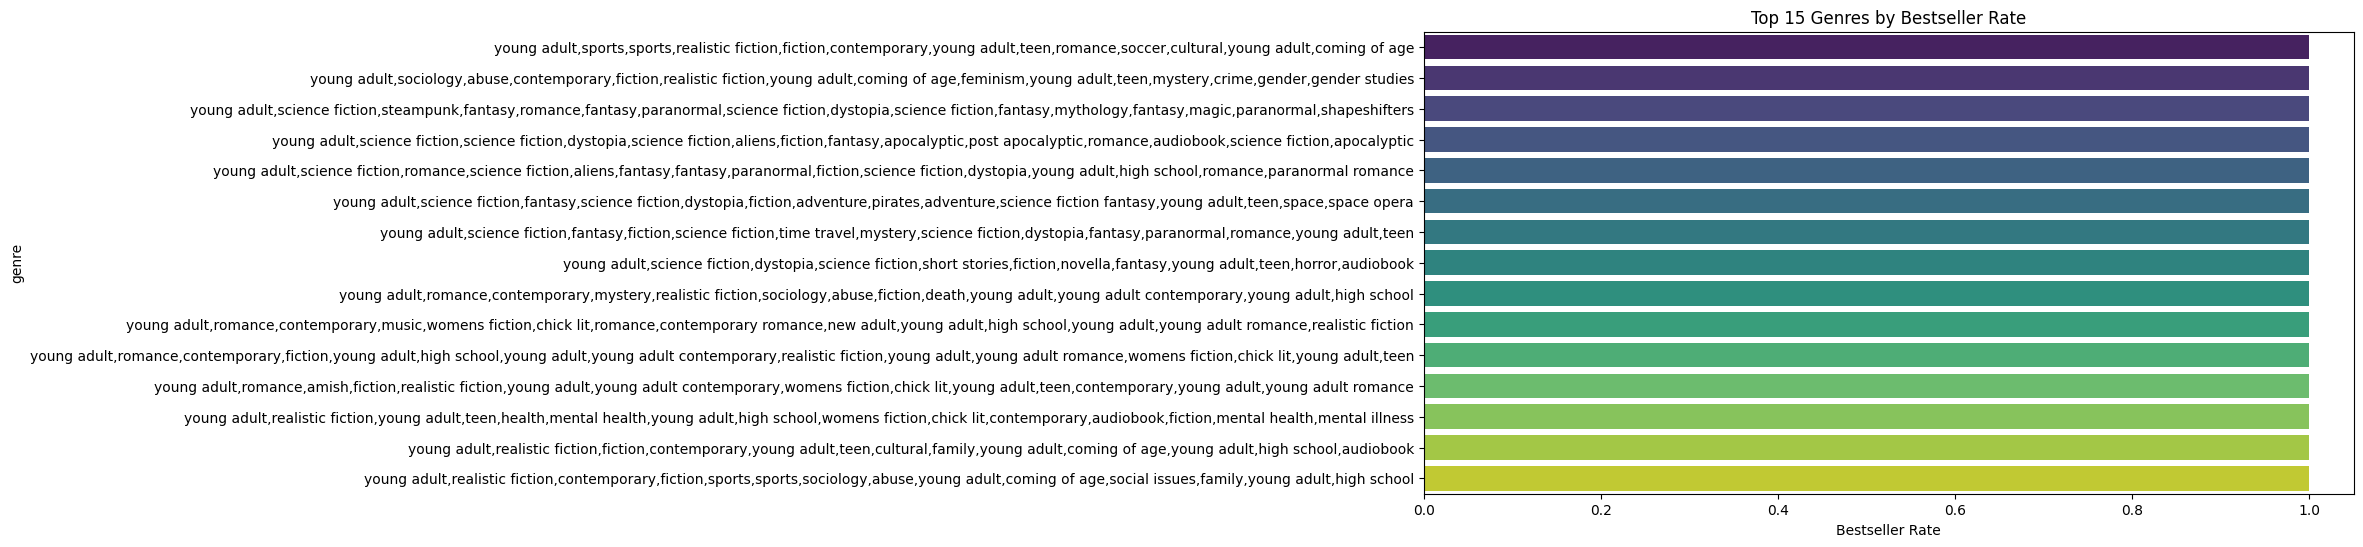

/tmp/ipython-input-345938811.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bestseller_by_format.values, y=bestseller_by_format.index, palette="viridis")
/tmp/ipython-input-345938811.py:32: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-345938811.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipython-input-345938811.py:33: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  plt.savefig(f"{output_dir}/bestseller_by_format.png")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


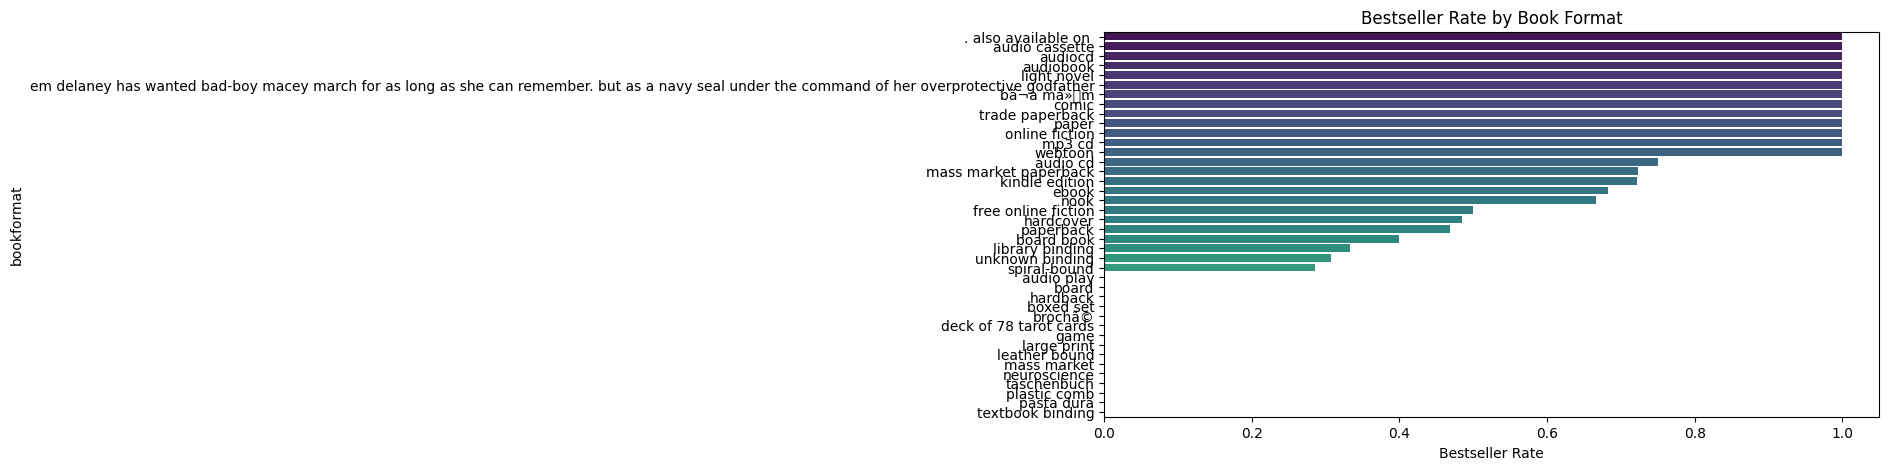

In [9]:
# --- Genre & Format ---
for col_name in ['genre', 'bookformat']:
    if col_name in eda_sample.columns:
        plt.figure(figsize=(12, 6))
        top_categories = eda_sample[col_name].value_counts().head(15)
        sns.barplot(x=top_categories.values, y=top_categories.index, palette="mako")
        plt.title(f"Top 15 Most Common {col_name.capitalize()}")
        plt.xlabel("Count")
        plt.tight_layout()
        plt.savefig(f"{output_dir}/top15_{col_name}.png")
        plt.show()
        plt.close()

# --- Bestseller by Category ---
if 'genre' in eda_sample.columns and 'bestseller' in eda_sample.columns:
    plt.figure(figsize=(12, 6))
    bestseller_by_genre = eda_sample.groupby('genre')['bestseller'].mean().sort_values(ascending=False).head(15)
    sns.barplot(x=bestseller_by_genre.values, y=bestseller_by_genre.index, palette="viridis")
    plt.title("Top 15 Genres by Bestseller Rate")
    plt.xlabel("Bestseller Rate")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/bestseller_by_genre.png")
    plt.show()
    plt.close()

if 'bookformat' in eda_sample.columns and 'bestseller' in eda_sample.columns:
    plt.figure(figsize=(10, 5))
    bestseller_by_format = eda_sample.groupby('bookformat')['bestseller'].mean().sort_values(ascending=False)
    sns.barplot(x=bestseller_by_format.values, y=bestseller_by_format.index, palette="viridis")
    plt.title("Bestseller Rate by Book Format")
    plt.xlabel("Bestseller Rate")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/bestseller_by_format.png")
    plt.show()
    plt.close()

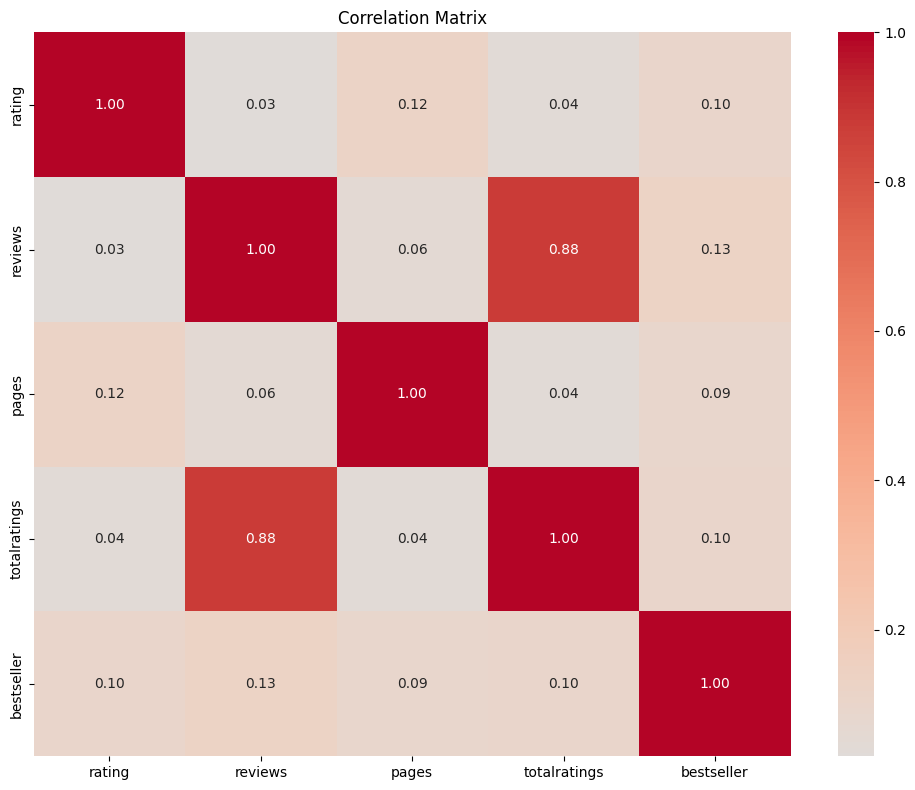

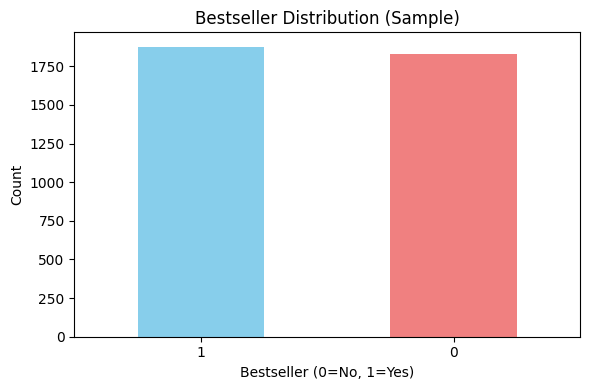

In [10]:
# --- Correlation Heatmap ---
plt.figure(figsize=(10, 8))
numeric_data = eda_sample.select_dtypes(include=[np.number])
if 'bestseller' in numeric_data.columns:
    corr_matrix = numeric_data.corr()
    sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f", center=0)
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/correlation_heatmap.png")
    plt.show()
    plt.close()

# --- Target Distribution ---
plt.figure(figsize=(6, 4))
eda_sample['bestseller'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title("Bestseller Distribution (Sample)")
plt.xlabel("Bestseller (0=No, 1=Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{output_dir}/bestseller_dist.png")
plt.show()
plt.close()

/tmp/ipython-input-2758014562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='viridis')


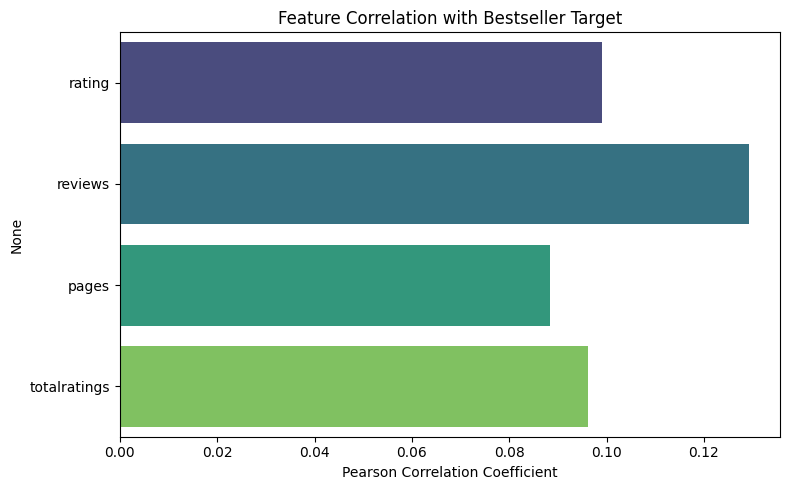

EDA visuals saved in: outputs/EDA_Visuals


In [11]:
# --- Correlation with Target ---
if 'bestseller' in eda_sample.columns:
    corr_with_target = numeric_data.corr()['bestseller'].drop('bestseller', errors='ignore')
    plt.figure(figsize=(8, 5))
    sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='viridis')
    plt.title("Feature Correlation with Bestseller Target")
    plt.xlabel("Pearson Correlation Coefficient")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/corr_with_target.png")
    plt.show()
    plt.close()

print(f"EDA visuals saved in: {output_dir}")

In [12]:
# =====================================================
# PREPARE DATA FOR MODELING WITH CATEGORICAL FEATURES
# =====================================================
print("\nPreparing data for modeling with categorical features...")

def create_features_with_categorical(row, top_genres, top_formats):
    """Create feature vector including numerical and one-hot encoded categorical features"""
    features = []

    # Numerical features
    if 'rating' in row.asDict():
        features.append(float(row['rating']))
    if 'reviews' in row.asDict():
        features.append(float(row['reviews']))
    if 'pages' in row.asDict():
        features.append(float(row['pages']))
    if 'totalratings' in row.asDict():
        features.append(float(row['totalratings']))

    # One-hot encode genre
    if 'genre' in row.asDict() and top_genres:
        genre = str(row['genre']).lower() if row['genre'] else 'unknown'
        for top_genre in top_genres:
            features.append(1.0 if genre == top_genre else 0.0)

    # One-hot encode bookformat
    if 'bookformat' in row.asDict() and top_formats:
        bookformat = str(row['bookformat']).lower() if row['bookformat'] else 'unknown'
        for top_format in top_formats:
            features.append(1.0 if bookformat == top_format else 0.0)

    return (np.array(features, dtype=float), float(row['bestseller']))

# Create RDD with features including categorical
rdd = df.rdd.map(lambda row: create_features_with_categorical(row, top_genres, top_formats))

# Count features to verify
first_features = rdd.first()[0]
print(f"Total features: {len(first_features)}")
print(f"   - Numerical features: 4")
print(f"   - Genre one-hot features: {len(top_genres) if 'genre' in df.columns else 0}")
print(f"   - Format one-hot features: {len(top_formats) if 'bookformat' in df.columns else 0}")

# Feature scaling: compute min/max for numerical features only
print("Applying feature scaling to numerical features...")
numerical_feature_count = 4  # rating, reviews, pages, totalratings

# Compute min/max only for numerical features
feat_min = rdd.map(lambda x: x[0][:numerical_feature_count]).reduce(lambda a, b: np.minimum(a, b))
feat_max = rdd.map(lambda x: x[0][:numerical_feature_count]).reduce(lambda a, b: np.maximum(a, b))
feat_range = feat_max - feat_min
feat_range[feat_range == 0] = 1.0  # avoid div-by-zero

def normalize_features_with_categorical(t):
    """Normalize only numerical features, leave categorical features as-is"""
    feats, label = t
    numerical_feats = feats[:numerical_feature_count]
    categorical_feats = feats[numerical_feature_count:]

    normalized_numerical = (numerical_feats - feat_min) / feat_range
    normalized_feats = np.concatenate([normalized_numerical, categorical_feats])

    return (normalized_feats, label)

rdd = rdd.map(normalize_features_with_categorical).cache()

# Split data into training and test sets
train_rdd, test_rdd = rdd.randomSplit([0.8, 0.2], seed=42)
print(f"Training data: {train_rdd.count()} records")
print(f"Test data: {test_rdd.count()} records")


Preparing data for modeling with categorical features...
Total features: 29
   - Numerical features: 4
   - Genre one-hot features: 15
   - Format one-hot features: 10
Applying feature scaling to numerical features...
Training data: 57207 records
Test data: 14254 records


In [13]:
# =====================================================
# DEFINE LOGISTIC REGRESSION FUNCTIONS
# =====================================================
def sigmoid(z):
    """Sigmoid activation function"""
    return 1 / (1 + np.exp(-np.clip(z, -250, 250)))  # Clip to avoid overflow

def predict(features, weights, bias):
    """Make predictions using current weights and bias"""
    z = np.dot(features, weights) + bias
    return sigmoid(z)

def compute_loss(rdd, weights, bias, reg_lambda=0.0):
    """Compute logistic loss with optional L2 regularization"""
    n = rdd.count()
    if n == 0:
        return 0.0

    # Binary cross-entropy loss
    total_loss = rdd.map(lambda x: -(
     x[1] * np.log(predict(x[0], weights, bias) + 1e-9) +
        (1 - x[1]) * np.log( (1 - predict(x[0], weights, bias)) + 1e-9 )
    )).sum()

    # Add L2 regularization
    reg_loss = (reg_lambda / (2 * n)) * np.sum(weights**2) if reg_lambda > 0 else 0

    return (total_loss / n) + reg_loss

def train_with_early_stopping(rdd, learning_rate, epochs, reg_lambda=0.0, patience=7, tol=1e-6, verbose=True):
    """Train logistic regression model with early stopping"""
    n_features = len(rdd.first()[0])
    weights = np.zeros(n_features)
    bias = 0.0
    losses = []
    best_loss = float('inf')
    best_weights = weights.copy()
    best_bias = bias
    patience_counter = 0

    for epoch in range(epochs):
        n = rdd.count()
        if n == 0:
            break

        # Compute gradients with L2 regularization
        gradients = rdd.map(lambda x: (
            (predict(x[0], weights, bias) - x[1]) * x[0],
            (predict(x[0], weights, bias) - x[1])
        )).reduce(lambda a, b: (a[0] + b[0], a[1] + b[1]))

        grad_w = gradients[0] / n
        grad_b = gradients[1] / n

        # Add regularization to weights gradient
        if reg_lambda > 0:
            grad_w += (reg_lambda / n) * weights

        # Update parameters
        weights -= learning_rate * grad_w
        bias -= learning_rate * grad_b

        # Compute loss
        loss = compute_loss(rdd, weights, bias, reg_lambda)
        losses.append(loss)

        # Early stopping check
        if loss < best_loss - tol:
            best_loss = loss
            best_weights = weights.copy()
            best_bias = bias
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch+1}")
                break

        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {loss:.6f}")

    return best_weights, best_bias, losses

def evaluate_rdd(rdd, weights, bias):
    """Evaluate model performance on given dataset"""
    predictions_and_labels = rdd.map(lambda x: (
        1 if predict(x[0], weights, bias) >= 0.5 else 0,
        x[1]
    )).cache()

    # Calculate confusion matrix components
    true_positives = predictions_and_labels.filter(lambda x: x[0] == 1 and x[1] == 1).count()
    false_positives = predictions_and_labels.filter(lambda x: x[0] == 1 and x[1] == 0).count()
    false_negatives = predictions_and_labels.filter(lambda x: x[0] == 0 and x[1] == 1).count()
    true_negatives = predictions_and_labels.filter(lambda x: x[0] == 0 and x[1] == 0).count()

    total = rdd.count()

    # Calculate metrics
    accuracy = (true_positives + true_negatives) / total if total > 0 else 0
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Calculate ROC curve data
    scores_and_labels = rdd.map(lambda x: (predict(x[0], weights, bias), x[1])).collect()
    scores, labels = zip(*scores_and_labels)

    # Sort by prediction score
    sorted_data = sorted(zip(scores, labels), key=lambda x: x[0], reverse=True)
    sorted_scores, sorted_labels = zip(*sorted_data)

    # Calculate TPR and FPR for ROC
    total_positives = sum(sorted_labels)
    total_negatives = len(sorted_labels) - total_positives

    tpr, fpr = [0], [0]
    current_positives = 0
    current_negatives = 0

    for score, label in sorted_data:
        if label == 1:
            current_positives += 1
        else:
            current_negatives += 1
        tpr.append(current_positives / total_positives if total_positives > 0 else 0)
        fpr.append(current_negatives / total_negatives if total_negatives > 0 else 0)

    # Calculate AUC using trapezoidal rule
    auc = np.trapz(tpr, fpr)

    predictions_and_labels.unpersist()

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": [[true_negatives, false_positives], [false_negatives, true_positives]],
        "fpr": fpr,
        "tpr": tpr,
        "auc": auc
    }

In [14]:
# =====================================================
# HYPERPARAMETER TUNING
# =====================================================
print("\nStarting hyperparameter tuning...")

# Define hyperparameter grid
grid = {
    "learning_rate": [0.01, 0.05],
    "reg_lambda": [0.001, 0.01],
    "epochs": [50]
}

best_score = -1
best_params = None
best_model = None

for lr in grid["learning_rate"]:
    for reg in grid["reg_lambda"]:
        for epochs in grid["epochs"]:
            print(f"Testing lr={lr}, reg={reg}, epochs={epochs}")
            w, b, losses = train_with_early_stopping(
                train_rdd, lr, epochs, reg, patience=7, tol=1e-6, verbose=False
            )
            metrics = evaluate_rdd(test_rdd, w, b)
            score = metrics["f1"]
            print(f"   -> F1 Score: {score:.4f}")

            if score > best_score:
                best_score = score
                best_params = {"learning_rate": lr, "reg_lambda": reg, "epochs": epochs}
                best_model = {"weights": w.copy(), "bias": float(b), "losses": losses.copy()}

print(f"Best hyperparameters: {best_params}")
print(f"Best F1 Score: {best_score:.4f}")

# Set best model parameters
weights = np.array(best_model["weights"])
bias = float(best_model["bias"])
losses = best_model["losses"]


Starting hyperparameter tuning...
Testing lr=0.01, reg=0.001, epochs=50


/tmp/ipython-input-535126552.py:131: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tpr, fpr)


   -> F1 Score: 0.5283
Testing lr=0.01, reg=0.01, epochs=50
   -> F1 Score: 0.5283
Testing lr=0.05, reg=0.001, epochs=50
   -> F1 Score: 0.5283
Testing lr=0.05, reg=0.01, epochs=50
   -> F1 Score: 0.5283
Best hyperparameters: {'learning_rate': 0.01, 'reg_lambda': 0.001, 'epochs': 50}
Best F1 Score: 0.5283


In [15]:
# =====================================================
# FINAL MODEL EVALUATION
# =====================================================
print("\nFinal Model Evaluation:")

final_metrics = evaluate_rdd(test_rdd, weights, bias)

print(f"Accuracy: {final_metrics['accuracy']:.4f}")
print(f"Precision: {final_metrics['precision']:.4f}")
print(f"Recall: {final_metrics['recall']:.4f}")
print(f"F1 Score: {final_metrics['f1']:.4f}")
print(f"AUC-ROC: {final_metrics['auc']:.4f}")
print(f"Confusion Matrix:")
print(f"   TN: {final_metrics['confusion_matrix'][0][0]}, FP: {final_metrics['confusion_matrix'][0][1]}")
print(f"   FN: {final_metrics['confusion_matrix'][1][0]}, TP: {final_metrics['confusion_matrix'][1][1]}")


Final Model Evaluation:
Accuracy: 0.5568
Precision: 0.5606
Recall: 0.4994
F1 Score: 0.5283
AUC-ROC: 0.6028
Confusion Matrix:
   TN: 4400, FP: 2772
   FN: 3545, TP: 3537


/tmp/ipython-input-535126552.py:131: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tpr, fpr)



 Generating evaluation visuals...


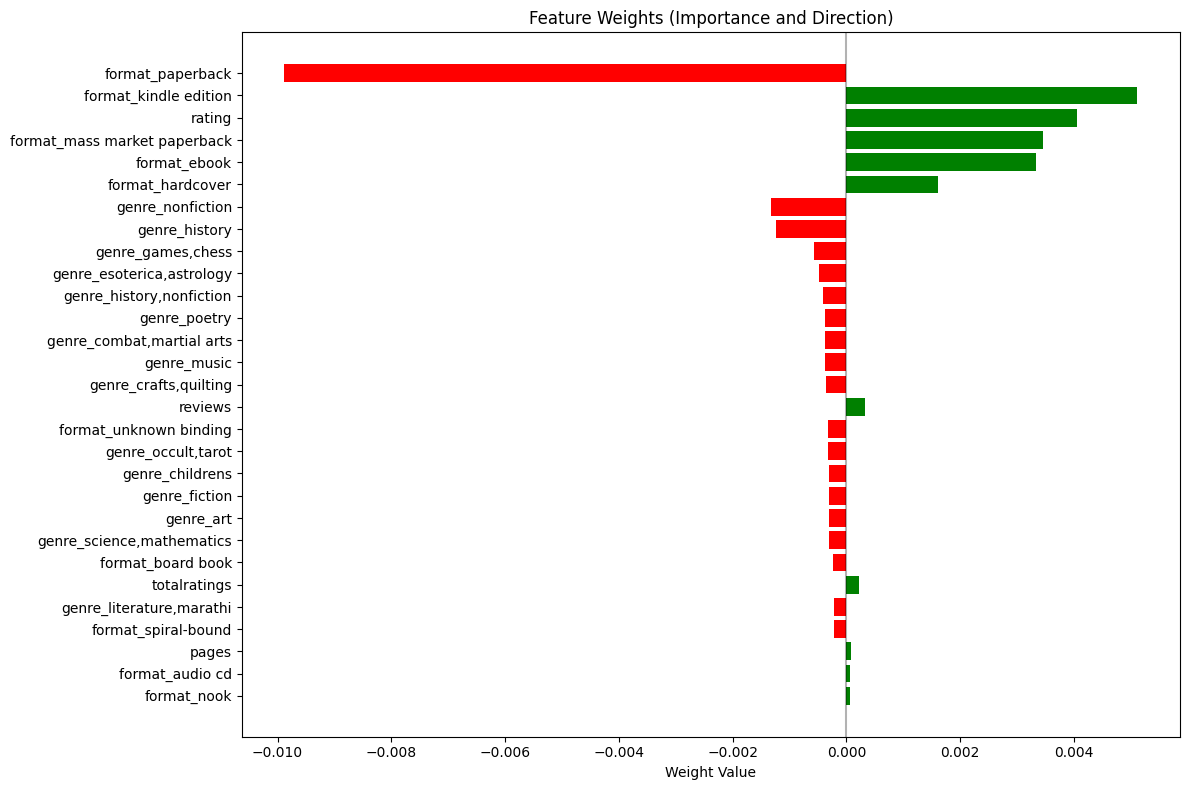

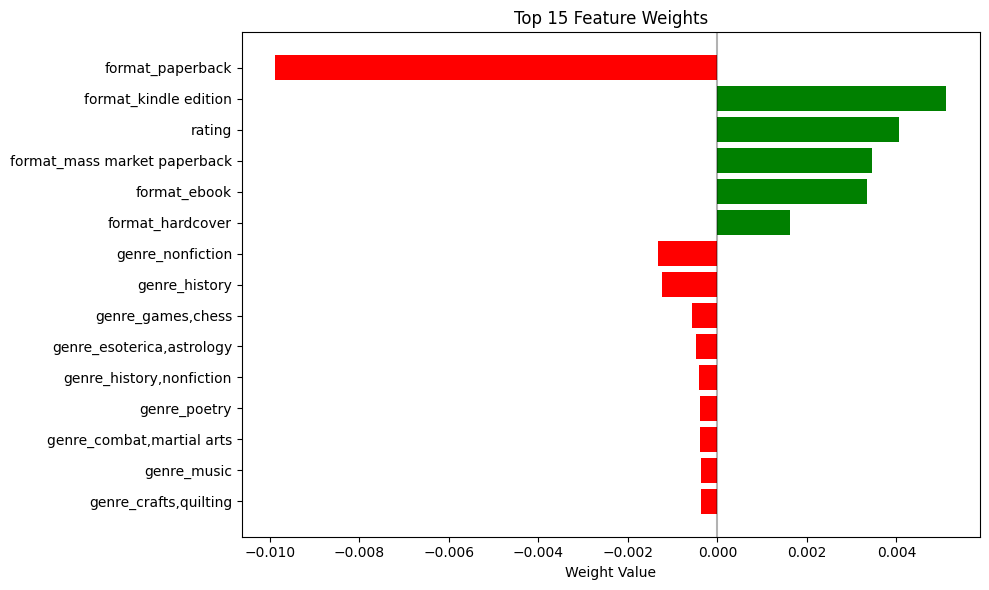

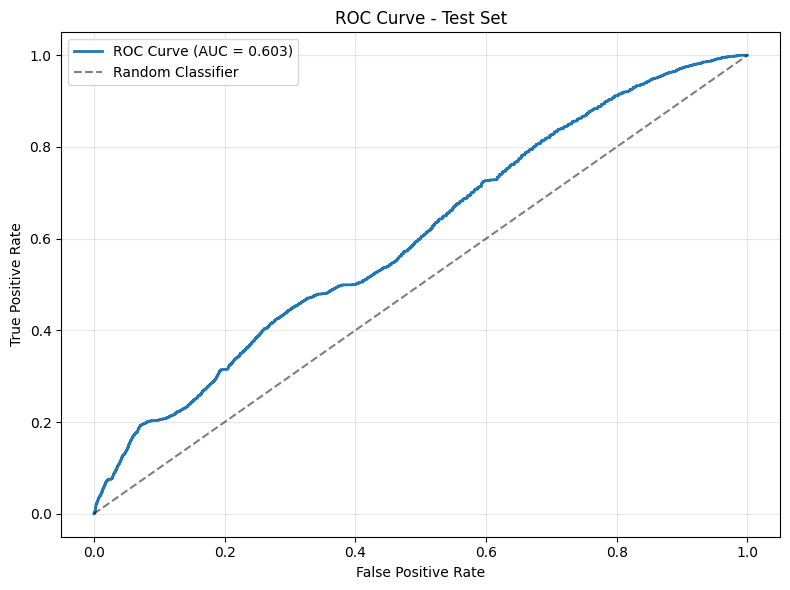

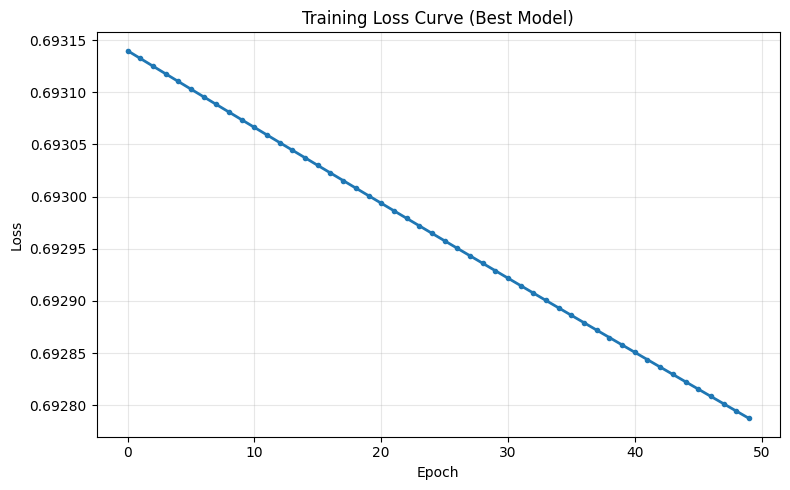

In [16]:
# =====================================================
# VISUALIZE RESULTS
# =====================================================
print("\n Generating evaluation visuals...")

# Create feature names for visualization
feature_names = ['rating', 'reviews', 'pages', 'totalratings']
if 'genre' in df.columns and top_genres:
    feature_names.extend([f'genre_{g}' for g in top_genres])
if 'bookformat' in df.columns and top_formats:
    feature_names.extend([f'format_{f}' for f in top_formats])

# --- Feature Importance ---
abs_weights = np.abs(weights)
order = np.argsort(abs_weights)[::-1]
sorted_features = [feature_names[i] for i in order]
sorted_weights = weights[order]

plt.figure(figsize=(12, 8))
colors = ['green' if w > 0 else 'red' for w in sorted_weights]
bars = plt.barh(range(len(sorted_weights)), sorted_weights, color=colors)
plt.yticks(range(len(sorted_weights)), sorted_features)
plt.title("Feature Weights (Importance and Direction)")
plt.xlabel("Weight Value")
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f"{output_dir}/feature_weights.png")
plt.show()
plt.close()

# --- Top 15 Feature Importance ---
plt.figure(figsize=(10, 6))
top_n = min(15, len(sorted_weights))
top_features = sorted_features[:top_n]
top_weights = sorted_weights[:top_n]
top_colors = ['green' if w > 0 else 'red' for w in top_weights]

bars = plt.barh(range(top_n), top_weights, color=top_colors)
plt.yticks(range(top_n), top_features)
plt.title(f"Top {top_n} Feature Weights")
plt.xlabel("Weight Value")
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f"{output_dir}/top_feature_weights.png")
plt.show()
plt.close()

# --- ROC Curve ---
plt.figure(figsize=(8, 6))
plt.plot(final_metrics["fpr"], final_metrics["tpr"],
         label=f"ROC Curve (AUC = {final_metrics['auc']:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/roc_curve.png")
plt.show()
plt.close()

# --- Loss Curve ---
plt.figure(figsize=(8, 5))
plt.plot(losses, marker='o', markersize=3, linewidth=2)
plt.title("Training Loss Curve (Best Model)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/loss_curve.png")
plt.show()
plt.close()

In [17]:
# =====================================================
# SAVE REPORT SUMMARY
# =====================================================
report_dir = "outputs"
os.makedirs(report_dir, exist_ok=True)
report_path = os.path.join(report_dir, "Model_Report.txt")

with open(report_path, "w") as f:
    f.write("LOGISTIC REGRESSION FROM SCRATCH REPORT\n")
    f.write("=========================================\n\n")
    f.write(f"Dataset: GoodReads_100k_books.csv\n")
    f.write(f"Total Records: {df.count()}\n")
    f.write(f"Training Records: {train_rdd.count()}\n")
    f.write(f"Test Records: {test_rdd.count()}\n")
    f.write(f"Total Features: {len(weights)}\n")
    f.write(f"  - Numerical Features: 4\n")
    f.write(f"  - Genre Features: {len(top_genres) if 'genre' in df.columns else 0}\n")
    f.write(f"  - Format Features: {len(top_formats) if 'bookformat' in df.columns else 0}\n\n")

    f.write("BEST HYPERPARAMETERS:\n")
    f.write(f"  Learning Rate: {best_params['learning_rate']}\n")
    f.write(f"  L2 Regularization: {best_params['reg_lambda']}\n")
    f.write(f"  Epochs: {best_params['epochs']}\n\n")

    f.write("MODEL PERFORMANCE:\n")
    f.write(f"  Accuracy: {final_metrics['accuracy']:.4f}\n")
    f.write(f"  Precision: {final_metrics['precision']:.4f}\n")
    f.write(f"  Recall: {final_metrics['recall']:.4f}\n")
    f.write(f"  F1 Score: {final_metrics['f1']:.4f}\n")
    f.write(f"  AUC-ROC: {final_metrics['auc']:.4f}\n\n")

    f.write("TOP 10 FEATURE WEIGHTS:\n")
    for i in range(min(10, len(weights))):
        feature_idx = order[i]
        f.write(f"  {feature_names[feature_idx]}: {weights[feature_idx]:.6f}\n")
    f.write(f"  Bias: {bias:.6f}\n\n")

    f.write("CONFUSION MATRIX:\n")
    f.write(f"  True Negatives: {final_metrics['confusion_matrix'][0][0]}\n")
    f.write(f"  False Positives: {final_metrics['confusion_matrix'][0][1]}\n")
    f.write(f"  False Negatives: {final_metrics['confusion_matrix'][1][0]}\n")
    f.write(f"  True Positives: {final_metrics['confusion_matrix'][1][1]}\n\n")

    f.write("CATEGORICAL FEATURES USED:\n")
    if top_genres:
        f.write("  Top Genres:\n")
        for genre in top_genres:
            f.write(f"    - {genre}\n")
    if top_formats:
        f.write("  Top Book Formats:\n")
        for format in top_formats:
            f.write(f"    - {format}\n")
    f.write("\n")

    f.write("VISUALS:\n")
    f.write("  All EDA and evaluation visuals saved in: outputs/EDA_Visuals/\n")

print(f"Comprehensive report saved as: {report_path}")

Comprehensive report saved as: outputs/Model_Report.txt


In [18]:
# =====================================================
# CLEANUP AND FINAL MESSAGE
# =====================================================
# Unpersist RDDs to free memory
rdd.unpersist()
train_rdd.unpersist()
test_rdd.unpersist()

print("\n" + "="*60)
print("="*60)
print(f"EDA Visuals: {output_dir}/")
print(f"Model Report: {report_path}")
print(f"Best F1 Score: {best_score:.4f}")
print(f"Final Test Accuracy: {final_metrics['accuracy']:.4f}")
print(f"Total Features Used: {len(weights)}")
print(f"   - Numerical: 4")
print(f"   - Categorical: {len(weights) - 4}")
print("="*60)

# Uncomment to stop Spark session when done
# spark.stop()


EDA Visuals: outputs/EDA_Visuals/
Model Report: outputs/Model_Report.txt
Best F1 Score: 0.5283
Final Test Accuracy: 0.5568
Total Features Used: 29
   - Numerical: 4
   - Categorical: 25
